Saving credit_data.csv to credit_data (1).csv
   income   debt  credit_score  payment_history  loan_amount  age  target
0   50000  10000           720               95        15000   30       1
1   30000  18000           580               60        25000   45       0
2   70000  12000           780               98        10000   28       1
3   45000  25000           610               70        20000   35       0
4   80000  10000           810               99         5000   40       1

Dataset Shape: (20, 7)

Missing Values:
income             0
debt               0
credit_score       0
payment_history    0
loan_amount        0
age                0
target             0
dtype: int64

Logistic Regression

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy             

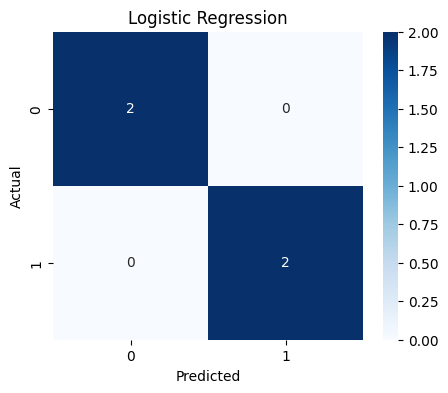

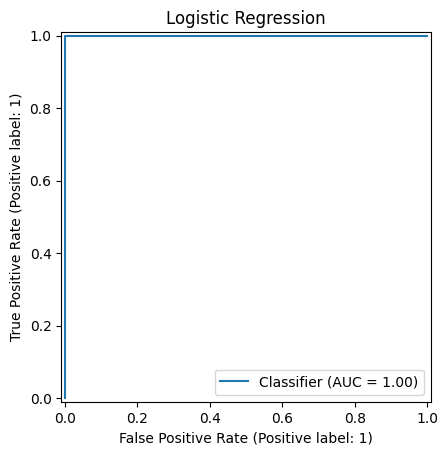


Decision Tree

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



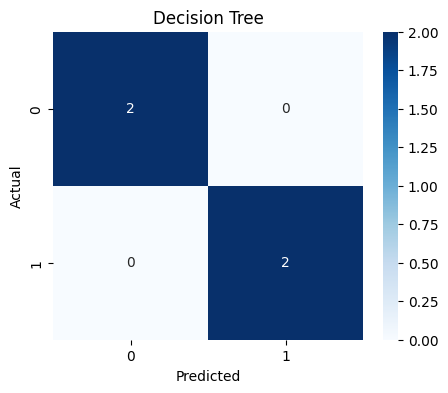

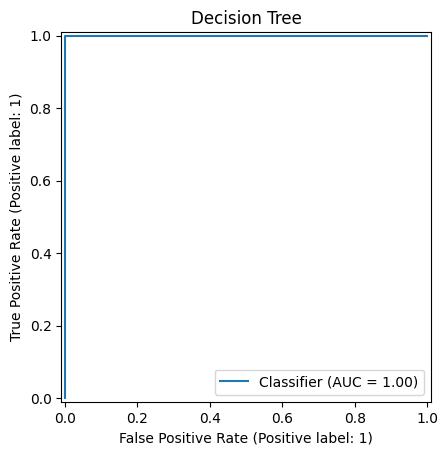


Random Forest

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



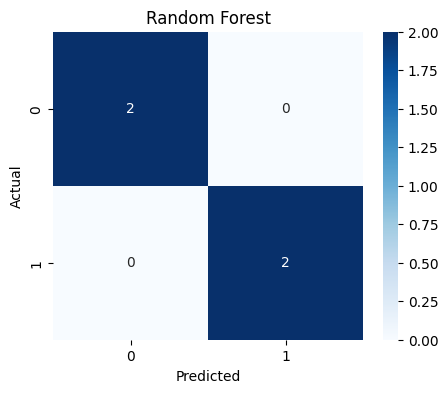

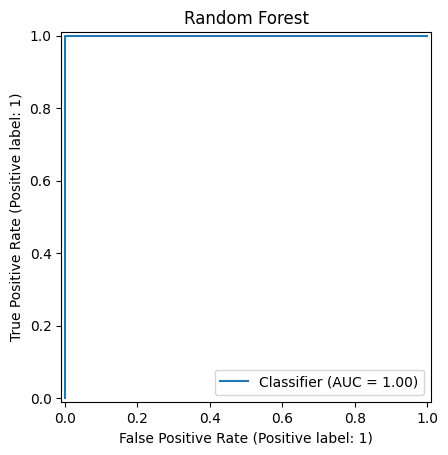

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       1.0        1.0     1.0       1.0      1.0
2        Random Forest       1.0        1.0     1.0       1.0      1.0

Best Model: Logistic Regression

Feature Importance
             Feature  Importance
1               debt       0.190
2       credit_score       0.165
6  debt_income_ratio       0.160
0             income       0.155
3    payment_history       0.140
4        loan_amount       0.140
5                age       0.050


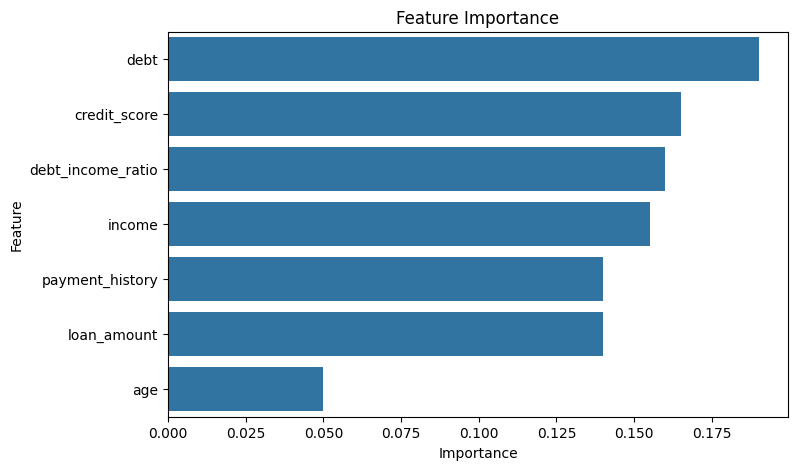


Prediction: Creditworthy


In [1]:
# ==========================================
# Creditworthiness Prediction Using Machine Learning
# ==========================================

# Install libraries (Run once in Google Colab)
!pip install -q scikit-learn pandas matplotlib seaborn

# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# ==========================================
# Load Dataset
# ==========================================

# Upload your CSV file
from google.colab import files
uploaded = files.upload()

# Replace filename if needed
df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())

# ==========================================
# Dataset Example Columns
# income
# debt
# credit_score
# payment_history
# loan_amount
# age
# target
#
# target:
# 1 = Creditworthy
# 0 = Not Creditworthy
# ==========================================

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# Handle Missing Values
# ==========================================

df.fillna(df.median(numeric_only=True), inplace=True)

# ==========================================
# Feature Engineering
# ==========================================

# Debt-to-Income Ratio
df["debt_income_ratio"] = df["debt"] / (df["income"] + 1)

# ==========================================
# Features and Target
# ==========================================

X = df.drop("target", axis=1)
y = df["target"]

# ==========================================
# Standardization
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

# ==========================================
# Training & Evaluation
# ==========================================

results = []

for name, model in models.items():

    print("\n====================================")
    print(name)
    print("====================================")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC AUC  :", roc)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(name)
    plt.show()

# ==========================================
# Comparison Table
# ==========================================

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])

print(results_df)

# ==========================================
# Best Model
# ==========================================

best_model_name = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model:", best_model_name)

# ==========================================
# Feature Importance (Random Forest)
# ==========================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))
sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()

# ==========================================
# Predict New Customer
# ==========================================

sample = pd.DataFrame({
    "income":[60000],
    "debt":[12000],
    "credit_score":[720],
    "payment_history":[95],
    "loan_amount":[15000],
    "age":[30]
})

sample["debt_income_ratio"] = sample["debt"]/(sample["income"]+1)

sample_scaled = scaler.transform(sample)

prediction = rf.predict(sample_scaled)

if prediction[0]==1:
    print("\nPrediction: Creditworthy")
else:
    print("\nPrediction: Not Creditworthy")